# **Assignment M2C2**

In [3]:
# Task 1
import pandas as pd
import numpy as np
from google.colab import files

url1 = "https://raw.githubusercontent.com/leonism/sample-superstore/master/data/superstore.csv"
df1 = pd.read_csv(url1, encoding='latin-1')
print(f"Loaded from URL: {df1.shape[0]} rows, {df1.shape[1]} columns")

Loaded from URL: 10800 rows, 21 columns


In [4]:
#Task 2:

print(f"Shape: {df1.shape}\n")
print("Column names, data types and non-null values:")
df1.info()
print(f"\n Data stats summary: ")
df1.describe()
print(df1.isnull().sum())

Shape: (10800, 21)

Column names, data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10800 non-null  object 
 1   Order ID       10800 non-null  object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null

In [5]:

# Task 3:
print(df1.shape)
missing_values = df1.isnull().sum()
missing_values_pct = df1.isnull().sum() / len(df1) * 100

missing_data = pd.DataFrame({"Missing count": missing_values,
                            "Missing percentage": missing_values_pct})
display(missing_data[missing_data["Missing count"] > 0])

df1.dropna(subset=['Order Date'], inplace=True)

numerical_cols = df1.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if df1[col].isnull().sum() > 0:
        median_val = df1[col].median()
        df1[col] = df1[col].fillna(median_val)

category_cols = df1.select_dtypes(include=["object"]).columns
for col in category_cols:
    if df1[col].isnull().sum() > 0:
        mode_val = df1[col].mode()[0]
        df1[col] = df1[col].fillna(mode_val)

print("\nMissing values after cleaning:")
print(df1.isnull().sum())
print(f"Current Shape: {df1.shape}")

(10800, 21)


,Missing count,Missing percentage
Order Date,806,7.462963
Ship Date,806,7.462963
Ship Mode,806,7.462963
Customer ID,806,7.462963
Customer Name,806,7.462963
Segment,806,7.462963
Country,806,7.462963
City,806,7.462963
State,806,7.462963
Postal Code,817,7.564815



Missing values after cleaning:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
Current Shape: (9994, 21)


In [6]:
# Task 4:
print("Shape before:", df1.shape)
print("Duplicate rows number: ", df1.duplicated().sum())
df1 = df1.drop_duplicates()
print("After duplicate deletion: ", df1.shape)

Shape before: (9994, 21)
Duplicate rows number:  0
After duplicate deletion:  (9994, 21)


In [7]:
# Task 5:
df1["Ship Date"] = pd.to_datetime(df1["Ship Date"])
df1["Order Date"] = pd.to_datetime(df1["Order Date"])

print(df1.dtypes)
df1[["Ship Date","Order Date"]].head()

Row ID                   object
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                float64
Discount                float64
Profit                  float64
dtype: object


,Ship Date,Order Date
0,2017-11-11,2017-11-08
1,2017-11-11,2017-11-08
2,2017-06-16,2017-06-12
3,2016-10-18,2016-10-11
4,2016-10-18,2016-10-11


In [8]:
# Task 6:
total_spendings = df1.groupby("Customer ID")["Sales"].sum().reset_index()
total_spendings.columns = ["Customer ID", "total_spendings"]

order_freq = df1.groupby("Customer ID")["Order ID"].nunique().reset_index()
order_freq.columns = ["Customer ID", "order_freq"]

avg_order = df1.groupby("Customer ID")["Sales"].mean().reset_index()
avg_order.columns = ["Customer ID", "avg_order"]

customer_summary = total_spendings.merge(order_freq, on='Customer ID').merge(avg_order, on='Customer ID')
customer_summary.head(10)


df1.to_csv('superstore_cleaned.csv', index=False)
customer_summary.to_csv('customer_summary.csv', index=False)

# **Assignment M2C3**



,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


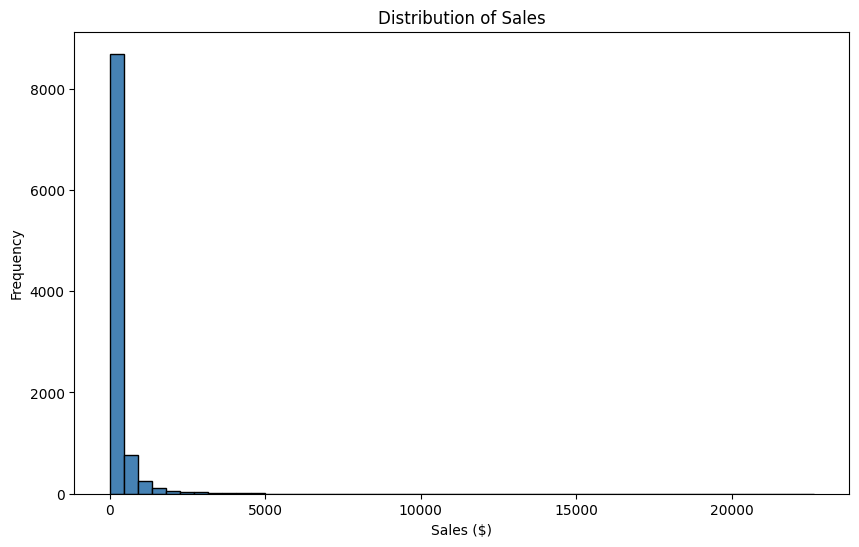

In [9]:
# Task 1
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('superstore_cleaned.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])

display(df.head())
# Sales histogram
plt.figure(figsize=(10, 6))
plt.hist(df['Sales'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Sales')
plt.xlabel('Sales ($)')
plt.ylabel('Frequency')
plt.show()

Graph is clearly skewed to the right which means that mean will be greater than median. This is caused by frequent small orders and a few expensive ones

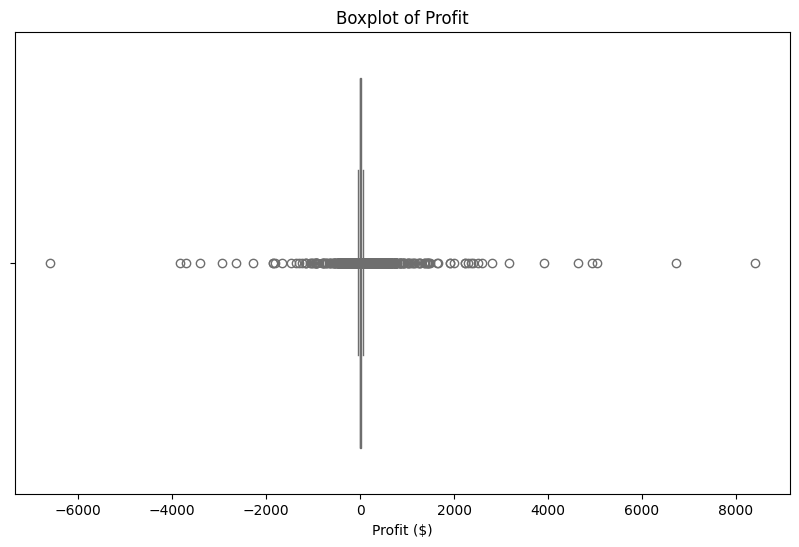

In [10]:
# Profit Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Profit'], color='lightcoral')
plt.title('Boxplot of Profit')
plt.xlabel('Profit ($)')
plt.show()


The Q1 and Q3 are vertical sides of the box, they're printed out. Outliers are clear, they usually extend over "whiskers" which are 1.5*IQR. Boxplot is heavily distorted by them

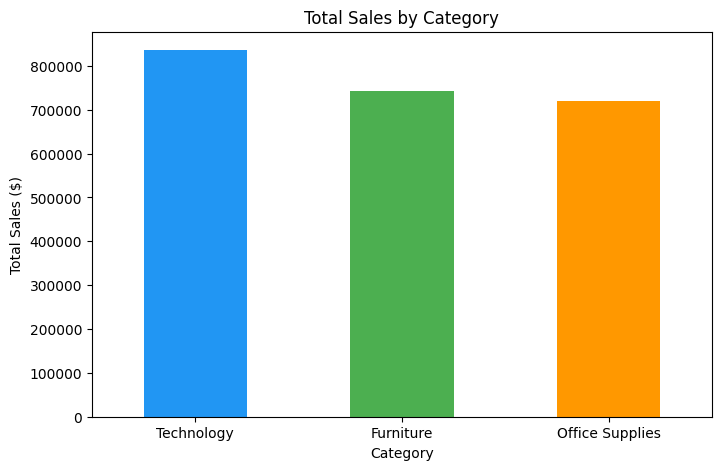

In [11]:
# Task 2
# Bar chart

# Category
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
cat_sales.plot(kind='bar', color=['#2196F3', '#4CAF50', '#FF9800'])
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.show()


Technology generates the most revenue. It's unsurprising since technology often require update to newer models and it costs a lot compared to supplies or cheap furniture

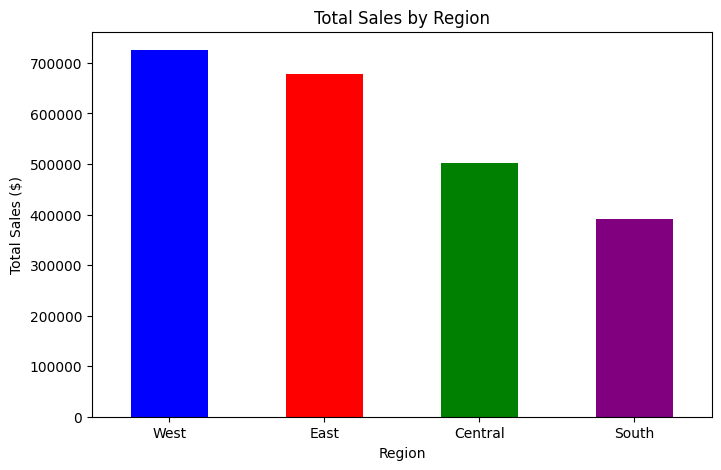

In [12]:
# Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
region_sales.plot(kind='bar', color=['blue', 'r', 'g', 'purple'])
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.show()


West generates the most revenue. I'm quite surprised to see west leading because most people live in east side of the 4 states The Giant Company operates. Big cities are located in the east too

In [13]:
# Task 3
Q1 = df['Profit'].quantile(0.25)
Q3 = df['Profit'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Profit'] < lower_bound) | (df['Profit'] > upper_bound)]


print(f"Q1: {Q1:,.2f} | Q3: {Q3:,.2f} | IQR: {IQR:,.2f}")
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")
print(f"Number of outliers: {len(outliers)} out of {len(df)} rows ({len(outliers)/len(df)*100:.2f}%)")

Q1: 1.73 | Q3: 29.36 | IQR: 27.64
Lower bound: -39.72, Upper bound: 70.82
Number of outliers: 1881 out of 9994 rows (18.82%)


I've found 1881 outliers. That's a significant amount/portion of outliers. There are both high-loss and high-profit outliers.

             Sales  Quantity  Discount    Profit
Sales     1.000000  0.200795 -0.028190  0.479064
Quantity  0.200795  1.000000  0.008623  0.066253
Discount -0.028190  0.008623  1.000000 -0.219487
Profit    0.479064  0.066253 -0.219487  1.000000


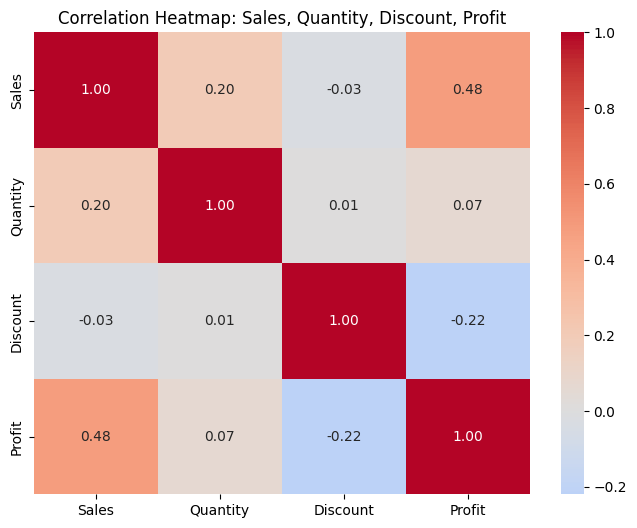

In [14]:
# Task 4
numerical_cols = df[['Sales', 'Quantity', 'Discount', 'Profit']]
corr_matrix = numerical_cols.corr()
print(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap: Sales, Quantity, Discount, Profit')
plt.show()

Profit/Sales have the highest correlation because higher revenue often means greater profit, though not always if margin is low. Profit/Discount is obviously negatively related becasue discounted products are usually sold at loss just to prevent additional expenses for storage.

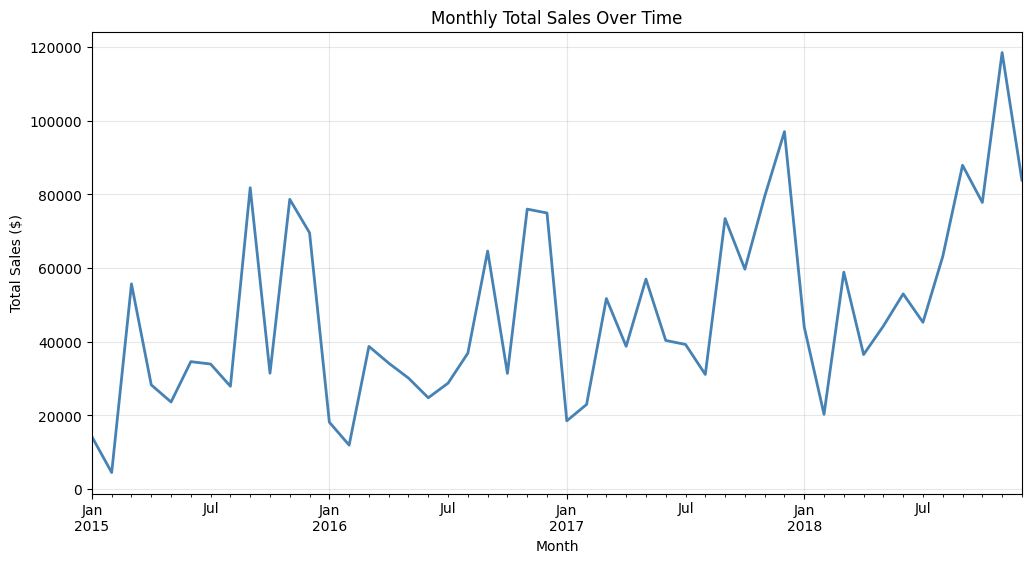

In [15]:
# Task 5
monthly_sales = df.resample('ME', on='Order Date')['Sales'].sum()

plt.figure(figsize=(12, 6))
monthly_sales.plot(color='steelblue', linewidth=2)
plt.title('Monthly Total Sales Over Time')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.grid(True, alpha=0.3)
plt.show()

There are noticable dips and peaks, mostly dips are related to Christmas holidays or end of school or fiscal year. Peaks are related to school and fiscal year begining, black friday discounts in November, pre - individual income tax returns period in March (followed by another dip)

Task 6

1. Most sales are low revenue but occasionaly high revenue sales are made which skew the graph to the right side. This is completely normal in big stores like Giant
2. All data is important, nothing should be removed. The graph can be zoomed in for the clearance but these outliers carry big revenue and increase mean over median
3. As I said before, discount are applied to items overstocking or with low sales numbers. To avoid additional expenses for storage discounts are applied
4. Despite seasonal spikes the graph looks good and and it even has positive long-term growth which is clear. Keep same strategies and apply new ones if market requires

# **Assignment M2C4**



In [16]:
# Task 1
import pandas as pd

df = pd.DataFrame({"name": ["Ali", "Zara", "Jasur"],
"age": [22, 28, 31],
"city": ["Tashkent", "Samarkand", "Bukhara"]
})

print(type(df["age"]))
print(type(df[["age",'city']]))
print(df.index)
# by default start at 0 and step 1

<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>
RangeIndex(start=0, stop=3, step=1)


In [17]:
# Task 1.2
new_data = pd.DataFrame({
    "name": ["John", "Don", "Qui-Gon"],
    "age": [25, 30, 50],
    "city": ["Salt Lake", "Palermo", "Theed"]
})

df = pd.concat([df, new_data], ignore_index=True)

In [18]:
# Task 2,1

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'

df = pd.read_csv(url)

In [19]:
# Task 2.2

display(df.head())
# Show first 5 rows, quick overview of data

print(f'\n Shape:{df.shape}\n')
# Number of rows and columns

df.info()
#Shows almost all general information about dataframe

display(df.describe())
# Calculates and shows statistical information about dataframe in a form of table

print(f'\n {df.isna().sum()}')
# Shows number of na values in each column

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



 Shape:(891, 12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [20]:
# Task 3.1
df['Age']
df[['Age', 'SibSp']]

df.loc[1]
# There's no text labels for '.loc' to be used properly
df.iloc[0]

,0
PassengerId,1
Survived,0
Pclass,3
Name,"Braund, Mr. Owen Harris"
Sex,male
Age,22.0
SibSp,1
Parch,0
Ticket,A/5 21171
Fare,7.25


In [21]:
# Task 3.2

display(df[(df.Age >= 25) & (df.Embarked == "S")])

display(df[(df.Survived > 0) & (df.Sex == "male")])
# & is used becasue AND would be used to compare the whole dataframe type and & compares every single data bit
# Parenthesis are used to get proper order because & has more priority than > == signs

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
880,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,NaN,S
881,882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S
883,884,0,2,"Banfield, Mr. Frederick James",male,28.0,0,0,C.A./SOTON 34068,10.5000,NaN,S
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
21,22,1,2,"Beesley, Mr. Lawrence",male,34.0,0,0,248698,13.0000,D56,S
23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.5000,A6,S
36,37,1,3,"Mamee, Mr. Hanna",male,NaN,0,0,2677,7.2292,NaN,C
55,56,1,1,"Woolner, Mr. Hugh",male,NaN,0,0,19947,35.5000,C52,S
...,...,...,...,...,...,...,...,...,...,...,...,...
838,839,1,3,"Chip, Mr. Chang",male,32.0,0,0,1601,56.4958,NaN,S
839,840,1,1,"Marechal, Mr. Pierre",male,NaN,0,0,11774,29.7000,C47,C
857,858,1,1,"Daly, Mr. Peter Denis",male,51.0,0,0,113055,26.5500,E17,S
869,870,1,3,"Johnson, Master. Harold Theodor",male,4.0,1,1,347742,11.1333,NaN,S


In [22]:
# Task 3.3

display(df.groupby("Sex")["Survived"].mean())
print(type(df.groupby("Sex")["Survived"].mean()))
#Answer: Series

df.groupby("Pclass").agg({
"Fare": "mean",
"PassengerId": "count"
})

,Survived
Sex,
female,0.742038
male,0.188908


<class 'pandas.core.series.Series'>


,Fare,PassengerId
Pclass,,
1,84.154687,216
2,20.662183,184
3,13.675550,491


In [23]:
# Task 3.4

lookup_df = pd.DataFrame({"Pclass": [1, 2, 3],
                          "Perks": ["All-inclusive", "Champagne", np.nan]
                          })

pd.merge(df, lookup_df, on="Pclass", how="left")
# Because no corresponding information exists in the lookup table, the new columns created by the merge will be populated with NaN values for those specific rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Perks
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,NaN
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,All-inclusive
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,NaN
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,All-inclusive
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Champagne
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,All-inclusive
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,All-inclusive


# **Assignment M2C5**



# Task 1.1
Basically, explanatory data help to visualize information in order to help understand it better for someone. Exploratory data helps to explore data and answer questions and analyze

#Task 1.2
Summary stats can be deceptive while proper graph can be useful to see how data is structured. Though it's important to notice that graphs can be also easily manipulated to decieve too.

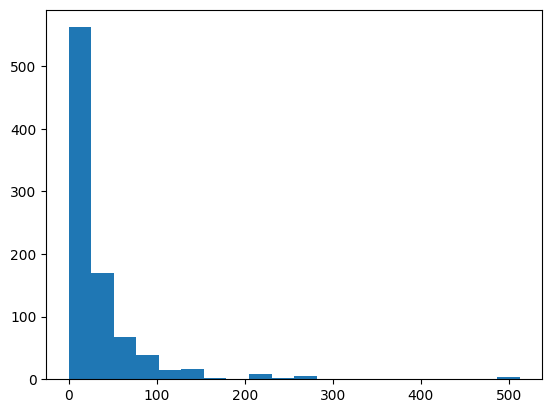

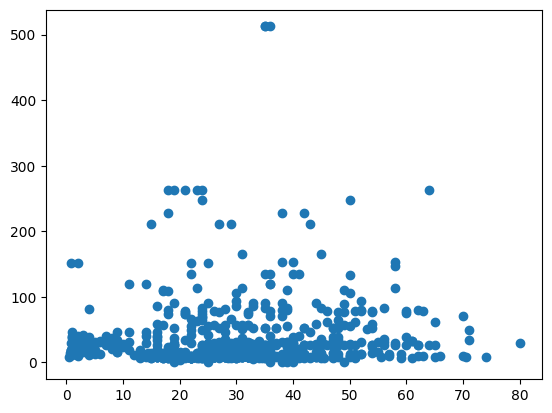

In [27]:
# Task 2.1
import matplotlib.pyplot as plt

plt.hist(df["Fare"], bins=20)
plt.show()

plt.scatter(df["Age"], df["Fare"])
plt.show()

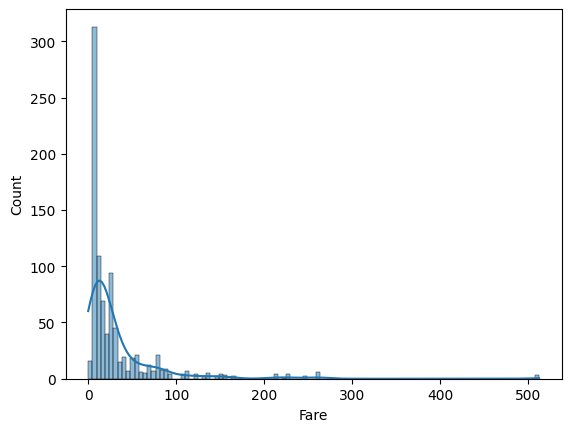

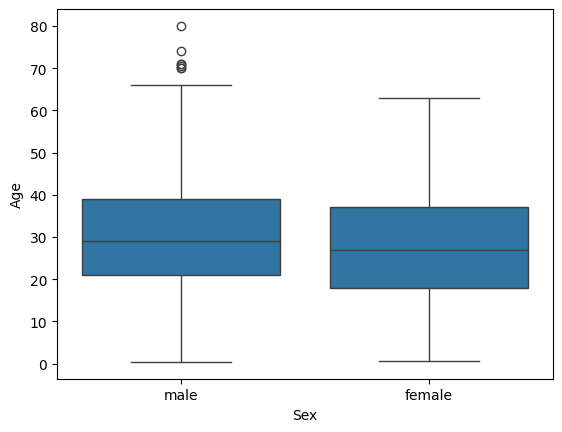

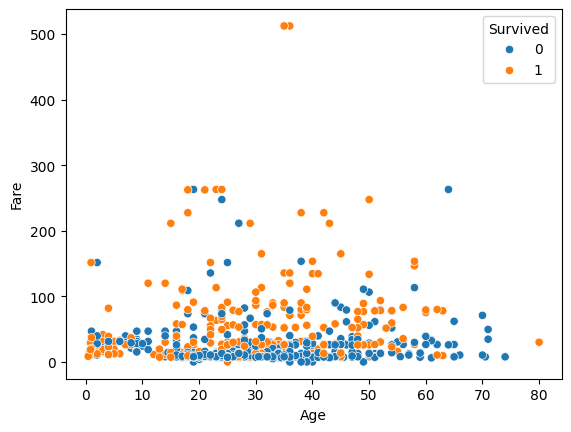

<Axes: >

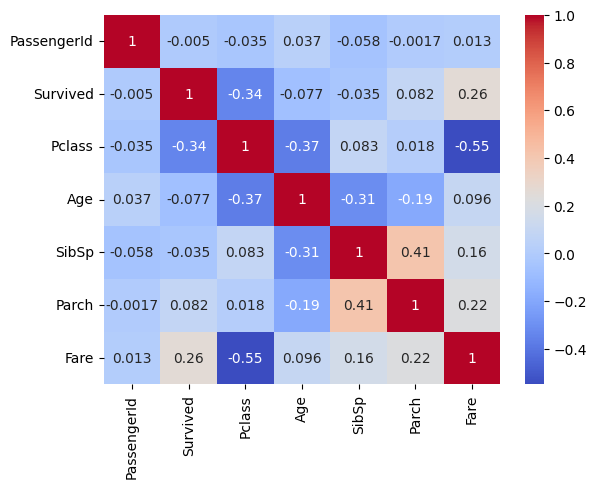

In [29]:
# Task 2.2
import seaborn as sns

sns.histplot(df, x="Fare", kde=True)
plt.show()

sns.boxplot(df, x="Sex", y="Age")
plt.show()

sns.scatterplot(data=df, x="Age", y="Fare", hue="Survived")
plt.show()

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

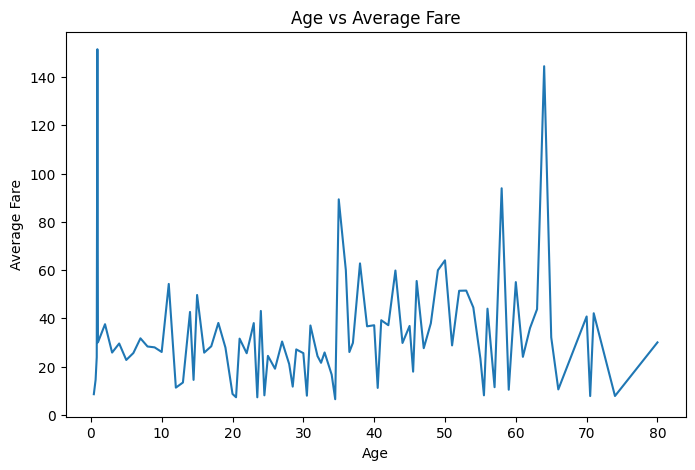

In [46]:
#Task 2.3
age_trends = df.groupby("Age")["Fare"].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot('Age', "Fare", data=age_trends)
ax.set_xlabel("Age")
ax.set_ylabel("Average Fare")
ax.set_title("Age vs Average Fare")
fig.savefig("out.png", dpi=150)

#Task 3.1
Graph 2.3 "Age vs Average Fare"
1. No. Age is usually self-explanatory, but currency for Fare is missing
2. N/A. Though not a bar chart, still starts at 0's
3. No, Bar chart would've been better
4. No, chart is clear without disruptive elements
5. Yes. Graph tries to explore relationship between age and money paid for the ticket, though it doesn't provide insightful data

#Task 3.2

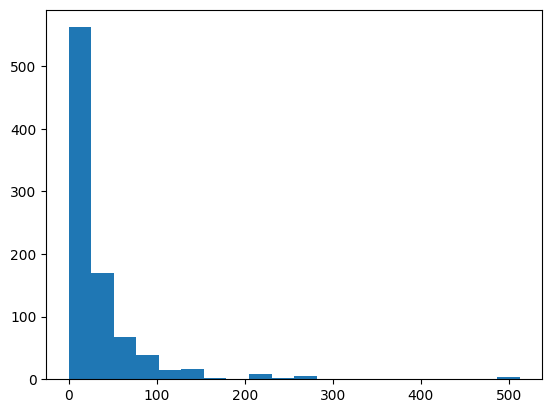

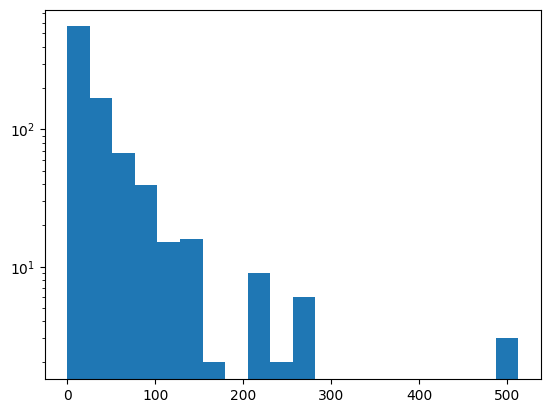

In [47]:
plt.hist(df["Fare"], bins=20)
plt.show()

plt.hist(df["Fare"], bins=20)
plt.yscale("log")
plt.show()

The log scale helps to "bring values closer". It's easier to see shape of data even though it can distort high freq parts it can also be useful to compare low freq. That happens because log scale increases exponentialy therefore it's easier to inspect tail of the distribution